# NarrativeNexus: The Dynamic Text Analysis Platform

NarrativeNexus is a Colab-ready text analysis platform that accepts pasted text or uploaded files and returns key themes, BBC News-trained topic/category signals, sentiment patterns, summaries, actionable recommendations, and visual reports.

**Supported inputs:** `.txt`, `.csv`, and `.docx` files, plus direct text input.

**Core methods:** preprocessing, BBC News dataset loading, TF-IDF vectorization, NMF topic modeling trained on BBC News when the dataset is available, optional category prediction, VADER sentiment analysis, extractive summarization, word-cloud generation, topic charts, sentiment charts, and a Gradio web interface.


## Project Architecture

```text
BBC News dataset, when available
        |
        v
Train TF-IDF + NMF topic model + optional category classifier
        |
        v
User text / uploaded file
        |
        v
Input handling and validation
        |
        v
Text cleaning, tokenization, stopword removal, lemmatization
        |
        v
BBC-trained TF-IDF transformation, or input-fitted fallback if the dataset is missing
        |
        +--> NMF topic analysis --> topic labels and keywords
        |
        +--> BBC category prediction --> predicted news area, when labels are available
        |
        +--> VADER sentiment analysis --> positive / neutral / negative tone
        |
        +--> Extractive summarization --> concise summary
        |
        v
Expanded insights engine and recommendation rules
        |
        v
Clear visual dashboard + downloadable report + Gradio app
```


## Methodology

1. **Data collection and input handling:** The app accepts direct text and file uploads in `.txt`, `.csv`, and `.docx` formats. CSV files are handled by joining text-like columns or by using a user-selected text column. The upload reader also supports Gradio file objects and dictionaries, which makes document upload more reliable across Gradio versions.
2. **BBC News model training:** At runtime, the notebook looks for a local BBC News dataset in common CSV and folder layouts; if it is missing and `kagglehub` is available, it downloads `hgultekin/bbcnewsarchive`, then trains TF-IDF, an NMF topic model with 30 topics by default, and an optional category classifier when category labels are available.
3. **Preprocessing:** Text is lowercased, cleaned, tokenized, filtered for stop words, and lemmatized to create a consistent representation for modeling.
4. **Topic and category analysis:** User text is transformed with the BBC-trained TF-IDF model and analyzed with the BBC-trained NMF model. If the dataset is not available, the notebook clearly falls back to fitting topic models on the current input so the app remains usable.
5. **Sentiment analysis:** VADER calculates positive, neutral, negative, and compound sentiment scores for each text segment.
6. **Summarization:** An extractive ranking method selects the highest-value sentences based on TF-IDF-style keyword importance.
7. **Visualization and reporting:** The platform produces word clouds, topic distributions, sentiment summaries, keyword tables, category predictions, expanded recommendations, and a downloadable Markdown report.
8. **User interface:** Gradio exposes the full pipeline as a clearer webpage inside the notebook with separated insights, tables, visuals, and report sections.


In [10]:
%%capture
!pip -q install gradio wordcloud python-docx matplotlib pandas numpy nltk scikit-learn kagglehub

In [11]:
import os
import re
import math
import json
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from wordcloud import WordCloud
import gradio as gr

try:
    import kagglehub
except Exception:
    kagglehub = None

try:
    import docx
except Exception:
    docx = None

warnings.filterwarnings('ignore')
plt.style.use('default')

for resource, package in [
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet', 'wordnet'),
    ('corpora/omw-1.4', 'omw-1.4'),
    ('sentiment/vader_lexicon', 'vader_lexicon'),
]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(package, quiet=True)

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
SIA = SentimentIntensityAnalyzer()

## Core Analysis Pipeline

The functions below keep the project reusable. They are written so the same analysis can run from a notebook cell or from the Gradio webpage.

In [12]:
def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', str(text or '')).strip()


def split_into_sentences(text):
    text = normalize_whitespace(text)
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if len(s.strip()) >= 20]


def split_into_aspect_segments(text, max_words=55):
    sentences = split_into_sentences(text)
    if not sentences:
        words = normalize_whitespace(text).split()
        return [' '.join(words[i:i + max_words]) for i in range(0, len(words), max_words) if words[i:i + max_words]]

    segments = []
    for sentence in sentences:
        parts = []
        for chunk in re.split(r';|\s+-\s+', sentence):
            chunk = chunk.strip()
            if not chunk:
                continue
            contrast_split = re.split(r'(?i)(?=\b(?:but|however|although|though|while|on the other hand|despite|even though)\b)', chunk)
            parts.extend(part.strip(' ,') for part in contrast_split if len(part.strip().split()) >= 6)

        for part in parts or [sentence]:
            words = part.split()
            if len(words) <= max_words:
                segments.append(part)
            else:
                for start in range(0, len(words), max_words):
                    segment = ' '.join(words[start:start + max_words])
                    if len(segment.split()) >= 6:
                        segments.append(segment)

    return segments or sentences


def split_into_documents(text, max_chunk_words=55):
    return split_into_aspect_segments(text, max_words=max_chunk_words)


def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = re.findall(r'[a-z]{3,}', text)
    tokens = [LEMMATIZER.lemmatize(token) for token in tokens if token not in STOP_WORDS]
    return tokens


def preprocess_document(text):
    return ' '.join(clean_and_tokenize(text))


def classify_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    if compound <= -0.05:
        return 'Negative'
    return 'Neutral'


def resolve_uploaded_path(uploaded_file):
    """Return a pathlib.Path for Gradio filepath, FileData, dict, or tempfile objects."""
    if not uploaded_file:
        return None

    if isinstance(uploaded_file, (list, tuple)):
        uploaded_file = uploaded_file[0] if uploaded_file else None
        if not uploaded_file:
            return None

    if isinstance(uploaded_file, dict):
        for key in ('path', 'name', 'orig_name'):
            value = uploaded_file.get(key)
            if value and Path(str(value)).exists():
                return Path(str(value))
        raise FileNotFoundError('The uploaded file path was not available from Gradio.')

    for attr in ('path', 'name'):
        value = getattr(uploaded_file, attr, None)
        if value and Path(str(value)).exists():
            return Path(str(value))

    candidate = Path(str(uploaded_file))
    if candidate.exists():
        return candidate

    raise FileNotFoundError(f'Uploaded file could not be found: {uploaded_file}')


def read_uploaded_file(uploaded_file, csv_text_column=None):
    path = resolve_uploaded_path(uploaded_file)
    if path is None:
        return ''

    suffix = path.suffix.lower()

    if suffix == '.txt':
        return path.read_text(encoding='utf-8', errors='ignore')

    if suffix == '.csv':
        df = pd.read_csv(path)
        if csv_text_column and csv_text_column in df.columns:
            columns = [csv_text_column]
        else:
            columns = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
        if not columns:
            raise ValueError('CSV file does not contain a usable text column.')
        return '\n'.join(df[columns].fillna('').astype(str).agg(' '.join, axis=1).tolist())

    if suffix == '.docx':
        if docx is None:
            raise ImportError('python-docx is required to read .docx files.')
        document = docx.Document(str(path))
        paragraphs = [paragraph.text for paragraph in document.paragraphs if paragraph.text.strip()]
        return '\n'.join(paragraphs)

    raise ValueError('Unsupported file type. Please upload .txt, .csv, or .docx.')


In [13]:
def extractive_summary(text, max_sentences=5):
    sentences = split_into_sentences(text)
    if not sentences:
        return normalize_whitespace(text)[:1200]

    cleaned_sentences = [preprocess_document(sentence) for sentence in sentences]
    valid_indices = [idx for idx, cleaned in enumerate(cleaned_sentences) if cleaned]
    if not valid_indices:
        return ' '.join(sentences[:max_sentences])

    vectorizer = TfidfVectorizer(max_features=3000)
    matrix = vectorizer.fit_transform([cleaned_sentences[idx] for idx in valid_indices])
    scores = np.asarray(matrix.sum(axis=1)).ravel()
    ranked = sorted(zip(valid_indices, scores), key=lambda item: item[1], reverse=True)
    chosen = sorted(idx for idx, _ in ranked[:max_sentences])
    return ' '.join(sentences[idx] for idx in chosen)


def build_topic_label(keywords):
    important = [word.title() for word in keywords[:3] if len(word) > 2]
    return ' / '.join(important) if important else 'General Theme'


def fit_topic_models(cleaned_docs, n_topics=30, n_words=10):
    usable_docs = [doc for doc in cleaned_docs if doc.strip()]
    if len(usable_docs) < 2:
        words = Counter(' '.join(usable_docs).split())
        keywords = [word for word, _ in words.most_common(n_words)]
        return {
            'nmf_model': None,
            'tfidf_vectorizer': None,
            'tfidf_matrix': None,
            'topics': [{'topic_id': 1, 'label': build_topic_label(keywords), 'keywords': keywords, 'weight': 1.0}],
            'doc_topic_matrix': np.ones((max(1, len(cleaned_docs)), 1)),
            'lda_topics': [],
        }

    n_topics = max(2, min(int(n_topics), len(usable_docs)))
    max_features = min(3000, max(100, len(set(' '.join(usable_docs).split()))))

    tfidf_vectorizer = TfidfVectorizer(max_features=max_features, min_df=1, max_df=0.95, ngram_range=(1, 2))
    tfidf_matrix = tfidf_vectorizer.fit_transform(usable_docs)
    feature_names = tfidf_vectorizer.get_feature_names_out()
    n_topics = max(1, min(n_topics, tfidf_matrix.shape[0], tfidf_matrix.shape[1]))

    nmf_model = NMF(n_components=n_topics, init='nndsvda', random_state=42, max_iter=600)
    doc_topic_matrix = nmf_model.fit_transform(tfidf_matrix)

    topics = []
    for topic_idx, component in enumerate(nmf_model.components_):
        top_indices = component.argsort()[-n_words:][::-1]
        keywords = [feature_names[i] for i in top_indices]
        topics.append({
            'topic_id': topic_idx + 1,
            'label': build_topic_label(keywords),
            'keywords': keywords,
            'weight': float(component[top_indices].sum()),
        })

    lda_topics = []
    try:
        count_vectorizer = CountVectorizer(max_features=max_features, min_df=1, max_df=0.95, ngram_range=(1, 2))
        count_matrix = count_vectorizer.fit_transform(usable_docs)
        count_features = count_vectorizer.get_feature_names_out()
        lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='batch')
        lda_model.fit(count_matrix)
        for topic_idx, component in enumerate(lda_model.components_):
            top_indices = component.argsort()[-n_words:][::-1]
            lda_topics.append({
                'topic_id': topic_idx + 1,
                'keywords': [count_features[i] for i in top_indices],
            })
    except Exception:
        lda_topics = []

    return {
        'nmf_model': nmf_model,
        'tfidf_vectorizer': tfidf_vectorizer,
        'tfidf_matrix': tfidf_matrix,
        'topics': topics,
        'doc_topic_matrix': doc_topic_matrix,
        'lda_topics': lda_topics,
    }

In [14]:
BBC_TEXT_COLUMNS = ['text', 'Text', 'content', 'Content', 'article', 'Article', 'description', 'Description', 'news', 'News']
BBC_LABEL_COLUMNS = ['category', 'Category', 'label', 'Label', 'class', 'Class']
BBC_DATASET_CANDIDATES = [
    Path(os.environ.get('BBC_NEWS_DATASET_PATH', '')) if os.environ.get('BBC_NEWS_DATASET_PATH') else None,
    Path('BBC News Train.csv'),
    Path('bbc-news-data.csv'),
    Path('bbc_news.csv'),
    Path('BBC News.csv'),
    Path('bbc-news.csv'),
    Path('bbc'),
    Path('BBC News Summary/News Articles'),
    Path('/content/BBC News Train.csv'),
    Path('/content/bbc-news-data.csv'),
    Path('/content/bbc'),
    Path('/content/BBC News Summary/News Articles'),
]
BBC_KAGGLE_DATASET = 'hgultekin/bbcnewsarchive'
BBC_NEWS_MODELS = None


def find_bbc_news_dataset(download_if_missing=True):
    for candidate in BBC_DATASET_CANDIDATES:
        if candidate and candidate.exists():
            return candidate

    if download_if_missing and kagglehub is not None:
        try:
            downloaded_path = Path(kagglehub.dataset_download(BBC_KAGGLE_DATASET))
            if downloaded_path.exists():
                return downloaded_path
        except Exception as exc:
            print(f'KaggleHub BBC News download skipped: {exc}')

    return None


def _first_existing_column(columns, names):
    for name in names:
        if name in columns:
            return name
    lowered = {str(col).lower(): col for col in columns}
    for name in names:
        if name.lower() in lowered:
            return lowered[name.lower()]
    return None


def load_bbc_news_dataset(dataset_path=None):
    dataset_path = Path(dataset_path) if dataset_path else find_bbc_news_dataset()
    if dataset_path is None or not dataset_path.exists():
        return pd.DataFrame(columns=['text', 'category']), 'BBC News dataset not found. Add it beside the notebook or set BBC_NEWS_DATASET_PATH.'

    rows = []
    if dataset_path.is_file():
        if dataset_path.suffix.lower() in {'.csv', '.tsv'}:
            sep = '\t' if dataset_path.suffix.lower() == '.tsv' else None
            df = pd.read_csv(dataset_path, sep=sep, engine='python')
            text_col = _first_existing_column(df.columns, BBC_TEXT_COLUMNS)
            label_col = _first_existing_column(df.columns, BBC_LABEL_COLUMNS)
            if text_col is None:
                object_cols = [col for col in df.columns if pd.api.types.is_string_dtype(df[col])]
                if not object_cols:
                    return pd.DataFrame(columns=['text', 'category']), f'No text column found in {dataset_path.name}.'
                text_col = max(object_cols, key=lambda col: df[col].fillna('').astype(str).str.len().mean())
            out = pd.DataFrame({
                'text': df[text_col].fillna('').astype(str),
                'category': df[label_col].fillna('bbcnews').astype(str) if label_col else 'bbcnews',
            })
        else:
            out = pd.DataFrame({'text': [dataset_path.read_text(encoding='utf-8', errors='ignore')], 'category': ['bbcnews']})
    else:
        table_files = sorted(dataset_path.glob('*.csv')) + sorted(dataset_path.glob('*.tsv'))
        if table_files:
            return load_bbc_news_dataset(table_files[0])

        for txt_path in dataset_path.rglob('*.txt'):
            text = txt_path.read_text(encoding='utf-8', errors='ignore')
            category = txt_path.parent.name if txt_path.parent != dataset_path else 'bbcnews'
            rows.append({'text': text, 'category': category})
        out = pd.DataFrame(rows, columns=['text', 'category'])

    out['text'] = out['text'].map(normalize_whitespace)
    out['category'] = out['category'].fillna('bbcnews').astype(str).str.strip().replace('', 'bbcnews')
    out = out[out['text'].str.split().str.len() >= 20].drop_duplicates(subset=['text']).reset_index(drop=True)
    if out.empty:
        return out, f'BBC News dataset was found at {dataset_path}, but no usable articles were loaded.'
    return out, f'Loaded {len(out):,} BBC News articles from {dataset_path}.'


def extract_nmf_topics(nmf_model, feature_names, n_words=10):
    topics = []
    for topic_idx, component in enumerate(nmf_model.components_):
        top_indices = component.argsort()[-n_words:][::-1]
        keywords = [feature_names[i] for i in top_indices]
        topics.append({
            'topic_id': topic_idx + 1,
            'label': build_topic_label(keywords),
            'keywords': keywords,
            'weight': float(component[top_indices].sum()),
        })
    return topics


def train_bbc_news_models(n_topics=30):
    dataset, status = load_bbc_news_dataset()
    if dataset.empty:
        return {
            'available': False,
            'status': status,
            'dataset_size': 0,
            'vectorizer': None,
            'nmf_model': None,
            'classifier': None,
            'categories': [],
            'topics': [],
            'category_topic_counts': pd.DataFrame(),
            'category_topic_proportions': pd.DataFrame(),
            'topic_sentiment_matrix': pd.DataFrame(),
            'topic_sentiment_stats': pd.DataFrame(),
            'topic_sentiment_insights': 'BBC dataset diagnostics are unavailable because the dataset was not loaded.',
        }

    dataset = dataset.copy()
    dataset['cleaned_text'] = dataset['text'].map(preprocess_document)
    dataset = dataset[dataset['cleaned_text'].str.strip().astype(bool)].reset_index(drop=True)
    if dataset.empty:
        return {
            'available': False,
            'status': 'BBC News dataset was loaded, but preprocessing removed every article.',
            'dataset_size': 0,
            'vectorizer': None,
            'nmf_model': None,
            'classifier': None,
            'categories': [],
            'topics': [],
            'category_topic_counts': pd.DataFrame(),
            'category_topic_proportions': pd.DataFrame(),
            'topic_sentiment_matrix': pd.DataFrame(),
            'topic_sentiment_stats': pd.DataFrame(),
            'topic_sentiment_insights': 'BBC dataset diagnostics are unavailable because the dataset was not loaded.',
        }
    cleaned_articles = dataset['cleaned_text'].tolist()
    n_topics = max(30, int(n_topics))
    n_topics = min(n_topics, len(cleaned_articles))
    min_df = 2 if len(cleaned_articles) >= 5 else 1
    vectorizer = TfidfVectorizer(max_features=5000, min_df=min_df, max_df=0.90, ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(cleaned_articles)
    n_topics = max(1, min(n_topics, matrix.shape[0], matrix.shape[1]))

    nmf_model = NMF(n_components=n_topics, init='nndsvda', random_state=42, max_iter=700)
    nmf_model.fit(matrix)

    classifier = None
    categories = sorted(dataset['category'].dropna().unique().tolist())
    if len(categories) > 1:
        classifier = MultinomialNB()
        classifier.fit(matrix, dataset['category'])

    topics = extract_nmf_topics(nmf_model, vectorizer.get_feature_names_out(), n_words=10)
    topic_lookup = {topic['topic_id'] - 1: topic['label'] for topic in topics}

    training_topic_matrix = nmf_model.transform(matrix)
    dataset['dominant_topic'] = training_topic_matrix.argmax(axis=1)
    dataset['topic_label'] = dataset['dominant_topic'].map(topic_lookup)
    dataset['sentiment_score'] = dataset['text'].map(lambda text: SIA.polarity_scores(text)['compound'])
    dataset['sentiment_label'] = dataset['sentiment_score'].map(classify_sentiment)

    topic_columns = list(range(nmf_model.components_.shape[0]))
    category_topic_counts = pd.crosstab(dataset['category'], dataset['dominant_topic']).reindex(columns=topic_columns, fill_value=0)
    category_topic_proportions = pd.crosstab(dataset['category'], dataset['dominant_topic'], normalize='index').reindex(columns=topic_columns, fill_value=0).round(6)

    sentiment_columns = ['Negative', 'Neutral', 'Positive']
    topic_labels = [topic_lookup[idx] for idx in topic_columns]
    topic_sentiment_matrix = pd.crosstab(dataset['topic_label'], dataset['sentiment_label']).reindex(index=topic_labels, columns=sentiment_columns, fill_value=0)

    grouped = dataset.groupby('topic_label', sort=False)
    topic_sentiment_stats = pd.DataFrame({
        'Topic': topic_labels,
        'Positive': [int(topic_sentiment_matrix.loc[label, 'Positive']) for label in topic_labels],
        'Negative': [int(topic_sentiment_matrix.loc[label, 'Negative']) for label in topic_labels],
        'Neutral': [int(topic_sentiment_matrix.loc[label, 'Neutral']) for label in topic_labels],
        'Total': [int(topic_sentiment_matrix.loc[label].sum()) for label in topic_labels],
        'Avg_Sentiment': [float(grouped['sentiment_score'].mean().get(label, 0.0)) for label in topic_labels],
    })
    topic_sentiment_stats['Positive%'] = np.where(topic_sentiment_stats['Total'] > 0, (topic_sentiment_stats['Positive'] / topic_sentiment_stats['Total'] * 100).round(1), 0.0)
    topic_sentiment_stats['Neutral%'] = np.where(topic_sentiment_stats['Total'] > 0, (topic_sentiment_stats['Neutral'] / topic_sentiment_stats['Total'] * 100).round(1), 0.0)
    topic_sentiment_stats['Negative%'] = np.where(topic_sentiment_stats['Total'] > 0, (topic_sentiment_stats['Negative'] / topic_sentiment_stats['Total'] * 100).round(1), 0.0)

    def _sentiment_description(score):
        if score >= 0.20:
            return 'Very Positive'
        if score >= 0.05:
            return 'Positive'
        if score <= -0.20:
            return 'Very Negative'
        if score <= -0.05:
            return 'Negative'
        return 'Neutral'

    insight_lines = ['## Topic Sentiment Insights']
    for _, row in topic_sentiment_stats.iterrows():
        insight_lines.extend([
            f'### {row["Topic"]}',
            f'- Overall sentiment: **{_sentiment_description(row["Avg_Sentiment"])}**',
            f'- Distribution: Positive **{row["Positive%"]:.1f}%**, Neutral **{row["Neutral%"]:.1f}%**, Negative **{row["Negative%"]:.1f}%**',
            f'- Sentiment score: **{row["Avg_Sentiment"]:.3f}**',
        ])
    topic_sentiment_insights = '\n'.join(insight_lines)

    return {
        'available': True,
        'status': status,
        'dataset_size': len(dataset),
        'vectorizer': vectorizer,
        'nmf_model': nmf_model,
        'classifier': classifier,
        'categories': categories,
        'topics': topics,
        'category_topic_counts': category_topic_counts,
        'category_topic_proportions': category_topic_proportions,
        'topic_sentiment_matrix': topic_sentiment_matrix,
        'topic_sentiment_stats': topic_sentiment_stats,
        'topic_sentiment_insights': topic_sentiment_insights,
    }


def apply_bbc_news_models(cleaned_docs, n_topics=30, n_words=10):
    if not BBC_NEWS_MODELS or not BBC_NEWS_MODELS.get('available'):
        return None

    usable_docs = [doc if doc.strip() else 'empty' for doc in cleaned_docs]
    vectorizer = BBC_NEWS_MODELS['vectorizer']
    nmf_model = BBC_NEWS_MODELS['nmf_model']
    matrix = vectorizer.transform(usable_docs)
    doc_topic_matrix = nmf_model.transform(matrix)
    topics = extract_nmf_topics(nmf_model, vectorizer.get_feature_names_out(), n_words=n_words)[:int(n_topics)]

    category_df = pd.DataFrame()
    classifier = BBC_NEWS_MODELS.get('classifier')
    if classifier is not None:
        predictions = classifier.predict(matrix)
        confidence = np.repeat(np.nan, len(predictions))
        if hasattr(classifier, 'predict_proba'):
            confidence = classifier.predict_proba(matrix).max(axis=1)
        category_df = pd.DataFrame({
            'Segment': [idx + 1 for idx in range(len(predictions))],
            'Predicted BBC Category': predictions,
            'Confidence': np.round(confidence, 3),
        })

    return {
        'nmf_model': nmf_model,
        'tfidf_vectorizer': vectorizer,
        'tfidf_matrix': matrix,
        'topics': topics,
        'doc_topic_matrix': doc_topic_matrix[:, :len(topics)] if len(topics) else doc_topic_matrix,
        'lda_topics': [],
        'category_df': category_df,
        'model_note': f'Using BBC News-trained TF-IDF + NMF model. {BBC_NEWS_MODELS["status"]}',
        'category_topic_counts': BBC_NEWS_MODELS.get('category_topic_counts', pd.DataFrame()),
        'category_topic_proportions': BBC_NEWS_MODELS.get('category_topic_proportions', pd.DataFrame()),
        'topic_sentiment_matrix': BBC_NEWS_MODELS.get('topic_sentiment_matrix', pd.DataFrame()),
        'topic_sentiment_stats': BBC_NEWS_MODELS.get('topic_sentiment_stats', pd.DataFrame()),
        'topic_sentiment_insights': BBC_NEWS_MODELS.get('topic_sentiment_insights', ''),
    }


BBC_NEWS_MODELS = train_bbc_news_models(n_topics=30)
print(BBC_NEWS_MODELS['status'])


Using Colab cache for faster access to the 'bbcnewsarchive' dataset.
Loaded 2,089 BBC News articles from /kaggle/input/bbcnewsarchive/bbc-news-data.csv.


In [15]:
def make_wordcloud(cleaned_text):
    fig, ax = plt.subplots(figsize=(9, 5))
    if cleaned_text.strip():
        cloud = WordCloud(width=1000, height=520, background_color='white', colormap='viridis').generate(cleaned_text)
        ax.imshow(cloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Key Terms Word Cloud', fontsize=14, weight='bold')
    fig.tight_layout()
    return fig



def make_empty_figure(message='No visualization available'):
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.axis('off')
    ax.text(0.5, 0.5, message, ha='center', va='center')
    fig.tight_layout()
    return fig


def make_heatmap_from_dataframe(df, title, colorbar_label='Value', value_format='.2f'):
    if df is None or df.empty:
        return make_empty_figure('BBC dataset diagnostics unavailable')

    plot_df = df.copy()
    fig_width = max(12, min(24, 0.55 * len(plot_df.columns)))
    fig_height = max(4, 0.55 * len(plot_df.index) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(plot_df.values.astype(float), aspect='auto', cmap='YlOrRd')
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xlabel('Dominant Topic')
    ax.set_ylabel('Category')
    ax.set_xticks(np.arange(len(plot_df.columns)))
    ax.set_xticklabels([str(col) for col in plot_df.columns], rotation=90)
    ax.set_yticks(np.arange(len(plot_df.index)))
    ax.set_yticklabels([str(idx) for idx in plot_df.index])

    if plot_df.shape[0] * plot_df.shape[1] <= 180:
        for row_idx in range(plot_df.shape[0]):
            for col_idx in range(plot_df.shape[1]):
                value = plot_df.iat[row_idx, col_idx]
                ax.text(col_idx, row_idx, format(float(value), value_format), ha='center', va='center', fontsize=7, color='black')

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(colorbar_label)
    fig.tight_layout()
    return fig

def make_sentiment_chart(sentiment_counts):
    labels = ['Negative', 'Neutral', 'Positive']
    values = [int(sentiment_counts.get(label, 0)) for label in labels]
    colors = ['#D55E00', '#777777', '#009E73']
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, values, color=colors)
    ax.set_title('Overall Sentiment Distribution', fontsize=14, weight='bold')
    ax.set_ylabel('Number of text segments')
    ax.grid(axis='y', alpha=0.25)
    for idx, value in enumerate(values):
        ax.text(idx, value, str(value), ha='center', va='bottom', fontsize=10)
    fig.tight_layout()
    return fig


def make_overall_sentiment_pie(sentiment_counts):
    labels = ['Negative', 'Neutral', 'Positive']
    values = [int(sentiment_counts.get(label, 0)) for label in labels]
    colors = ['#D55E00', '#777777', '#009E73']
    fig, ax = plt.subplots(figsize=(6, 5))
    if sum(values) == 0:
        ax.axis('off')
        ax.text(0.5, 0.5, 'No sentiment data available', ha='center', va='center')
    else:
        ax.pie(values, labels=labels, colors=colors, autopct=lambda pct: f'{pct:.1f}%' if pct > 0 else '0.0%', startangle=90)
        ax.set_title('Overall Sentiment Share', fontsize=14, weight='bold')
    fig.tight_layout()
    return fig


def make_topic_sentiment_chart(topic_sentiment_stats):
    if topic_sentiment_stats is None or topic_sentiment_stats.empty:
        return make_empty_figure('Topic-wise sentiment unavailable')

    chart_df = topic_sentiment_stats[topic_sentiment_stats['Total'] > 0].copy()
    if chart_df.empty:
        return make_empty_figure('Topic-wise sentiment unavailable')
    chart_df = chart_df.sort_values('Total', ascending=True)
    y = np.arange(len(chart_df))
    fig_height = max(5, 0.38 * len(chart_df) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    negative = chart_df['Negative'].astype(int).to_numpy()
    neutral = chart_df['Neutral'].astype(int).to_numpy()
    positive = chart_df['Positive'].astype(int).to_numpy()
    ax.barh(y, negative, label='Negative', color='#D55E00')
    ax.barh(y, neutral, left=negative, label='Neutral', color='#777777')
    ax.barh(y, positive, left=negative + neutral, label='Positive', color='#009E73')
    ax.set_yticks(y)
    ax.set_yticklabels(chart_df['Topic'].astype(str))
    ax.set_xlabel('Number of text segments')
    ax.set_title('Topic-wise Sentiment Distribution', fontsize=14, weight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=0.2)
    fig.tight_layout()
    return fig



def make_sentiment_dashboard(sentiment_counts, topic_sentiment_stats):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    labels = ['Negative', 'Neutral', 'Positive']
    colors = {'Negative': '#D55E00', 'Neutral': '#777777', 'Positive': '#009E73'}

    chart_df = topic_sentiment_stats[topic_sentiment_stats['Total'] > 0].copy() if topic_sentiment_stats is not None and not topic_sentiment_stats.empty else pd.DataFrame()
    if chart_df.empty:
        for ax in axes.ravel():
            ax.axis('off')
            ax.text(0.5, 0.5, 'Topic-wise sentiment unavailable', ha='center', va='center')
        fig.tight_layout()
        return fig

    chart_df = chart_df.sort_values('Topic')
    x = np.arange(len(chart_df))
    bottom = np.zeros(len(chart_df))
    for label in labels:
        values = chart_df[label].astype(int).to_numpy()
        axes[0, 0].bar(x, values, bottom=bottom, label=label, color=colors[label])
        bottom += values
    axes[0, 0].set_title('Sentiment Distribution per Topic', fontsize=14, weight='bold')
    axes[0, 0].set_ylabel('Number of Text Segments')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(chart_df['Topic'].astype(str), rotation=45, ha='right', fontsize=8)
    axes[0, 0].legend(title='Sentiment')
    axes[0, 0].grid(axis='y', alpha=0.2)

    avg_df = chart_df.sort_values('Avg_Sentiment', ascending=True)
    bar_colors = ['#D55E00' if value < -0.05 else '#777777' if value <= 0.05 else '#009E73' for value in avg_df['Avg_Sentiment']]
    axes[0, 1].barh(avg_df['Topic'].astype(str), avg_df['Avg_Sentiment'], color=bar_colors)
    axes[0, 1].axvline(0, color='black', linewidth=0.8)
    axes[0, 1].set_title('Average Sentiment per Topic', fontsize=14, weight='bold')
    axes[0, 1].set_xlabel('Average Sentiment Score')
    axes[0, 1].tick_params(axis='y', labelsize=8)
    axes[0, 1].grid(axis='x', alpha=0.2)

    pie_values = [int(sentiment_counts.get(label, 0)) for label in labels]
    if sum(pie_values) == 0:
        axes[1, 0].axis('off')
        axes[1, 0].text(0.5, 0.5, 'No sentiment data available', ha='center', va='center')
    else:
        axes[1, 0].pie(pie_values, labels=labels, colors=[colors[label] for label in labels], autopct=lambda pct: f'{pct:.1f}%', startangle=90)
        axes[1, 0].set_title('Overall Sentiment Distribution', fontsize=14, weight='bold')

    heat_df = chart_df.set_index('Topic')[['Negative%', 'Neutral%', 'Positive%']]
    image = axes[1, 1].imshow(heat_df.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    axes[1, 1].set_title('Sentiment Distribution per Topic (Percentages)', fontsize=14, weight='bold')
    axes[1, 1].set_xticks(np.arange(3))
    axes[1, 1].set_xticklabels(['Negative', 'Neutral', 'Positive'])
    axes[1, 1].set_yticks(np.arange(len(heat_df.index)))
    axes[1, 1].set_yticklabels(heat_df.index.astype(str), fontsize=8)
    for row_idx in range(heat_df.shape[0]):
        for col_idx in range(heat_df.shape[1]):
            value = heat_df.iat[row_idx, col_idx]
            axes[1, 1].text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', fontsize=7, color='black')
    cbar = fig.colorbar(image, ax=axes[1, 1])
    cbar.set_label('Percentage (%)')

    fig.tight_layout()
    return fig

def make_topic_chart(topic_df):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    if not topic_df.empty:
        chart_df = topic_df.sort_values('Documents', ascending=True)
        ax.barh(chart_df['Topic'], chart_df['Documents'], color='#4C78A8')
    ax.set_title('Dominant Topic Distribution', fontsize=14, weight='bold')
    ax.set_xlabel('Number of text segments')
    ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    return fig



def sentiment_overall_label(avg_compound, sentiment_counts=None):
    sentiment_counts = sentiment_counts or {}
    positive = int(sentiment_counts.get('Positive', 0))
    neutral = int(sentiment_counts.get('Neutral', 0))
    negative = int(sentiment_counts.get('Negative', 0))
    if neutral >= positive and neutral >= negative and abs(avg_compound) < 0.05:
        return 'Neutral'
    if avg_compound >= 0.20:
        return 'Very Positive'
    if avg_compound >= 0.05:
        return 'Positive'
    if avg_compound <= -0.20:
        return 'Very Negative'
    if avg_compound <= -0.05:
        return 'Negative'
    return 'Neutral'


def sentiment_distribution_text(sentiment_counts):
    total = max(1, sum(int(sentiment_counts.get(label, 0)) for label in ['Positive', 'Neutral', 'Negative']))
    lines = []
    for label in ['Positive', 'Neutral', 'Negative']:
        count = int(sentiment_counts.get(label, 0))
        percent = count / total * 100
        lines.append(f'- {label}: **{count} segment(s)** ({percent:.1f}%)')
    return '\n'.join(lines)


def build_document_topic_sentiment(topic_df, dominant_indices, sentiment_df):
    labels = ['Negative', 'Neutral', 'Positive']
    if topic_df.empty or sentiment_df.empty:
        return pd.DataFrame(columns=labels), pd.DataFrame(columns=['Topic', 'Positive', 'Neutral', 'Negative', 'Total', 'Avg_Sentiment', 'Positive%', 'Neutral%', 'Negative%', 'Overall Sentiment'])

    topic_labels = [topic for topic in topic_df['Topic'].tolist()]
    rows = []
    for idx, sentiment_row in enumerate(sentiment_df.itertuples(index=False)):
        topic_idx = int(dominant_indices[idx]) if idx < len(dominant_indices) else 0
        topic_label = topic_labels[topic_idx] if topic_idx < len(topic_labels) else topic_labels[0]
        rows.append({
            'Topic': topic_label,
            'Sentiment': sentiment_row.Label,
            'Compound': float(sentiment_row.Compound),
        })

    doc_topic_sentiment = pd.DataFrame(rows)
    matrix = pd.crosstab(doc_topic_sentiment['Topic'], doc_topic_sentiment['Sentiment']).reindex(index=topic_labels, columns=labels, fill_value=0)
    stats_rows = []
    for topic_label in topic_labels:
        topic_rows = doc_topic_sentiment[doc_topic_sentiment['Topic'] == topic_label]
        total = int(matrix.loc[topic_label].sum()) if topic_label in matrix.index else 0
        avg = float(topic_rows['Compound'].mean()) if not topic_rows.empty else 0.0
        positive = int(matrix.loc[topic_label, 'Positive']) if topic_label in matrix.index else 0
        neutral = int(matrix.loc[topic_label, 'Neutral']) if topic_label in matrix.index else 0
        negative = int(matrix.loc[topic_label, 'Negative']) if topic_label in matrix.index else 0
        safe_total = max(1, total)
        stats_rows.append({
            'Topic': topic_label,
            'Positive': positive,
            'Neutral': neutral,
            'Negative': negative,
            'Total': total,
            'Avg_Sentiment': round(avg, 3),
            'Positive%': round(positive / safe_total * 100, 1),
            'Neutral%': round(neutral / safe_total * 100, 1),
            'Negative%': round(negative / safe_total * 100, 1),
            'Overall Sentiment': sentiment_overall_label(avg, {'Positive': positive, 'Neutral': neutral, 'Negative': negative}),
        })
    return matrix, pd.DataFrame(stats_rows)


def topic_sentiment_summary_markdown(topic_sentiment_stats):
    if topic_sentiment_stats is None or topic_sentiment_stats.empty:
        return '- Topic-wise sentiment is unavailable because no topic segments were generated.'
    lines = []
    for _, row in topic_sentiment_stats.iterrows():
        lines.append(
            f'- **{row["Topic"]}**: {row["Overall Sentiment"]}; Positive {row["Positive%"]:.1f}%, Neutral {row["Neutral%"]:.1f}%, Negative {row["Negative%"]:.1f}% (avg score {row["Avg_Sentiment"]:.3f})'
        )
    return '\n'.join(lines)

def generate_recommendations(sentiment_counts, topics, summary, category_df=None):
    total = max(1, sum(sentiment_counts.values()))
    negative_ratio = sentiment_counts.get('Negative', 0) / total
    positive_ratio = sentiment_counts.get('Positive', 0) / total
    top_topic = topics[0]['label'] if topics else 'the main theme'

    recommendations = []
    if negative_ratio >= 0.35:
        recommendations.append(f'Prioritize deeper review of negative language around **{top_topic}** and identify the root causes behind repeated concerns.')
    elif positive_ratio >= 0.50:
        recommendations.append(f'Use the strong positive signal around **{top_topic}** as evidence for messaging, stakeholder updates, or follow-up campaigns.')
    else:
        recommendations.append(f'Treat **{top_topic}** as the primary area for monitoring because it appears most central in the text.')

    if len(topics) >= 2:
        recommendations.append(f'Compare **{topics[0]["label"]}** with **{topics[1]["label"]}** to understand whether the discussion is concentrated or split across themes.')

    if category_df is not None and not category_df.empty:
        top_category = category_df['Predicted BBC Category'].mode().iloc[0]
        recommendations.append(f'Use the **{top_category}** BBC News category signal to compare this text with similar newsroom coverage patterns.')

    if len(summary.split()) > 80:
        recommendations.append('Convert the summary into a short action brief with owners, deadlines, and success metrics before sharing it with decision makers.')
    else:
        recommendations.append('Collect more text samples if this is intended for strategic decision-making, because a larger input usually gives more stable topic patterns.')

    return recommendations


def build_report(title, total_words, topics, lda_topics, sentiment_counts, avg_compound, summary, recommendations, model_note=None, category_df=None):
    lines = [
        f'# {title}',
        '',
        '## Overview',
        f'- Model used: {model_note or 'Input-fitted topic model fallback'}',
        f'- Total words analyzed: {total_words:,}',
        f'- Average sentiment compound score: {avg_compound:.3f}',
        f'- Sentiment split: Positive {sentiment_counts.get("Positive", 0)}, Neutral {sentiment_counts.get("Neutral", 0)}, Negative {sentiment_counts.get("Negative", 0)}',
        '',
        '## Executive Summary',
        summary or 'No summary available.',
        '',
        '## NMF Topics',
    ]

    for topic in topics:
        lines.append(f'- Topic {topic["topic_id"]}: {topic["label"]} - {", ".join(topic["keywords"][:8])}')

    if category_df is not None and not category_df.empty:
        lines.extend(['', '## BBC Category Predictions'])
        category_counts = category_df['Predicted BBC Category'].value_counts().to_dict()
        for category, count in category_counts.items():
            lines.append(f'- {category}: {count} segment(s)')

    if lda_topics:
        lines.extend(['', '## LDA Comparison Topics'])
        for topic in lda_topics:
            lines.append(f'- Topic {topic["topic_id"]}: {", ".join(topic["keywords"][:8])}')

    lines.extend(['', '## Actionable Recommendations'])
    for item in recommendations:
        lines.append(f'- {item.replace("**", "")}')

    return '\n'.join(lines)

In [16]:
def analyze_text(raw_text, title='NarrativeNexus Text Analysis', n_topics=30, summary_sentences=5):
    raw_text = normalize_whitespace(raw_text)
    if len(raw_text.split()) < 20:
        raise ValueError('Please provide at least 20 words so the platform can extract meaningful themes.')

    documents = split_into_documents(raw_text)
    cleaned_docs = [preprocess_document(doc) for doc in documents]
    cleaned_corpus = ' '.join(cleaned_docs)

    topic_result = apply_bbc_news_models(cleaned_docs, n_topics=n_topics) if 'apply_bbc_news_models' in globals() else None
    if topic_result is None:
        topic_result = fit_topic_models(cleaned_docs, n_topics=n_topics)
        topic_result['category_df'] = pd.DataFrame()
        topic_result['model_note'] = BBC_NEWS_MODELS['status'] if 'BBC_NEWS_MODELS' in globals() else 'BBC News model was not initialized.'
        topic_result['category_topic_counts'] = pd.DataFrame()
        topic_result['category_topic_proportions'] = pd.DataFrame()
        topic_result['topic_sentiment_matrix'] = pd.DataFrame()
        topic_result['topic_sentiment_stats'] = pd.DataFrame()
        topic_result['topic_sentiment_insights'] = 'BBC dataset diagnostics are unavailable because the BBC dataset model was not loaded.'

    topics = topic_result['topics']
    doc_topic_matrix = topic_result['doc_topic_matrix']
    category_df = topic_result.get('category_df', pd.DataFrame())
    model_note = topic_result.get('model_note', 'Input-fitted topic model fallback')
    category_topic_counts = topic_result.get('category_topic_counts', pd.DataFrame())
    category_topic_proportions = topic_result.get('category_topic_proportions', pd.DataFrame())
    topic_sentiment_matrix = topic_result.get('topic_sentiment_matrix', pd.DataFrame())
    topic_sentiment_stats = topic_result.get('topic_sentiment_stats', pd.DataFrame())
    topic_sentiment_insights = topic_result.get('topic_sentiment_insights', '')

    dominant_indices = doc_topic_matrix.argmax(axis=1) if len(doc_topic_matrix) else np.array([0])
    topic_counts = Counter((idx + 1) for idx in dominant_indices)
    topic_rows = []
    for topic in topics:
        topic_rows.append({
            'Topic': f'Topic {topic["topic_id"]}: {topic["label"]}',
            'Keywords': ', '.join(topic['keywords'][:10]),
            'Documents': int(topic_counts.get(topic['topic_id'], 0)),
        })
    topic_df = pd.DataFrame(topic_rows)

    sentiment_rows = []
    for idx, doc in enumerate(documents, start=1):
        scores = SIA.polarity_scores(doc)
        sentiment_rows.append({
            'Segment': idx,
            'Segment Preview': doc[:120] + ('...' if len(doc) > 120 else ''),
            'Positive': scores['pos'],
            'Neutral': scores['neu'],
            'Negative': scores['neg'],
            'Compound': scores['compound'],
            'Label': classify_sentiment(scores['compound']),
        })
    sentiment_df = pd.DataFrame(sentiment_rows)
    sentiment_counts = sentiment_df['Label'].value_counts().reindex(['Positive', 'Neutral', 'Negative'], fill_value=0).to_dict()
    avg_compound = float(sentiment_df['Compound'].mean())
    overall_sentiment = sentiment_overall_label(avg_compound, sentiment_counts)
    document_topic_sentiment_matrix, document_topic_sentiment_stats = build_document_topic_sentiment(topic_df, dominant_indices, sentiment_df)

    summary = extractive_summary(raw_text, max_sentences=int(summary_sentences))
    recommendations = generate_recommendations(sentiment_counts, topics, summary, category_df=category_df)
    report = build_report(
        title=title,
        total_words=len(raw_text.split()),
        topics=topics,
        lda_topics=topic_result['lda_topics'],
        sentiment_counts=sentiment_counts,
        avg_compound=avg_compound,
        summary=summary,
        recommendations=recommendations,
        model_note=model_note,
        category_df=category_df,
    )

    wordcloud_fig = make_wordcloud(cleaned_corpus)
    sentiment_fig = make_sentiment_chart(sentiment_counts)
    sentiment_pie_fig = make_overall_sentiment_pie(sentiment_counts)
    document_topic_sentiment_fig = make_topic_sentiment_chart(document_topic_sentiment_stats)
    sentiment_dashboard_fig = make_sentiment_dashboard(sentiment_counts, document_topic_sentiment_stats)
    topic_fig = make_topic_chart(topic_df)
    category_topic_heatmap_fig = make_heatmap_from_dataframe(
        category_topic_proportions,
        title='BBC Category vs Dominant Topic: Normalized Distribution',
        colorbar_label='Proportion',
        value_format='.2f',
    )

    top_topic = topic_df.iloc[0]['Topic'] if not topic_df.empty else 'No topic identified'
    sentiment_distribution_lines = sentiment_distribution_text(sentiment_counts)
    topic_sentiment_lines = topic_sentiment_summary_markdown(document_topic_sentiment_stats)
    category_summary = 'BBC category classifier is unavailable because the dataset labels were not found.'
    if not category_df.empty:
        category_counts = category_df['Predicted BBC Category'].value_counts()
        category_summary = ', '.join(f'{category}: {count}' for category, count in category_counts.items())

    topic_lines = chr(10).join(
        f'- **{row.Topic}**: {row.Documents} segment(s); keywords: {row.Keywords}'
        for row in topic_df.itertuples(index=False)
    ) or '- No topic rows available.'
    recommendation_lines = chr(10).join(f'- {item}' for item in recommendations)

    insight_markdown = f"""
## Model and Input Status
- **Model path:** {model_note}
- **Words analyzed:** {len(raw_text.split()):,}
- **Text segments analyzed:** {len(documents):,}
- **Dominant theme:** {top_topic}
- **Overall sentiment:** {overall_sentiment}
- **Average compound score:** **{avg_compound:.3f}**

## Executive Summary
{summary}

## BBC News Category Signal
- {category_summary}

## Topic Insights
{topic_lines}

## Overall Sentiment Distribution
{sentiment_distribution_lines}
- Interpretation: scores above 0.05 are positive, below -0.05 are negative, and the rest are neutral. The overall label uses the average compound score and the segment distribution.

## Topic-wise Sentiment Distribution
{topic_sentiment_lines}

## Actionable Recommendations
{recommendation_lines}
""".strip()

    report_path = Path('/content/narrativenexus_report.md') if Path('/content').exists() else Path('narrativenexus_report.md')
    report_path.write_text(report, encoding='utf-8')

    return {
        'insight_markdown': insight_markdown,
        'topic_df': topic_df,
        'sentiment_df': sentiment_df,
        'category_df': category_df,
        'category_topic_counts': category_topic_counts,
        'category_topic_proportions': category_topic_proportions,
        'topic_sentiment_matrix': topic_sentiment_matrix,
        'topic_sentiment_stats': topic_sentiment_stats,
        'document_topic_sentiment_matrix': document_topic_sentiment_matrix,
        'document_topic_sentiment_stats': document_topic_sentiment_stats,
        'topic_sentiment_insights': topic_sentiment_insights,
        'category_topic_heatmap_fig': category_topic_heatmap_fig,
        'wordcloud_fig': wordcloud_fig,
        'sentiment_fig': sentiment_fig,
        'sentiment_pie_fig': sentiment_pie_fig,
        'document_topic_sentiment_fig': document_topic_sentiment_fig,
        'sentiment_dashboard_fig': sentiment_dashboard_fig,
        'topic_fig': topic_fig,
        'report_path': str(report_path),
    }


## Quick Notebook Test

Run this cell to verify the pipeline before launching the web app.

,Topic,Keywords,Documents
0,Topic 1: Company / Sale / Firm,"company, sale, firm, share, profit, market, sa...",3
1,Topic 2: Tax / Budget / Spending,"tax, budget, spending, council, council tax, c...",0
2,Topic 3: England / Wale / Rugby,"england, wale, rugby, six nation, robinson, fr...",2


,Label,Compound,Segment Preview
0,Positive,0.7650,Customer feedback from the latest product laun...
1,Neutral,0.0000,Several users said the charts helped their tea...
2,Negative,-0.5994,"However, some customers reported frustration w..."
3,Positive,0.4019,Support teams also noticed repeated questions ...
4,Positive,0.8625,The recommended next step is to improve the fi...


,Segment,Predicted BBC Category,Confidence
0,1,business,0.487
1,2,tech,0.277
2,3,business,0.503
3,4,politics,0.256
4,5,business,0.321


## Model and Input Status
- **Model path:** Using BBC News-trained TF-IDF + NMF model. Loaded 2,089 BBC News articles from /kaggle/input/bbcnewsarchive/bbc-news-data.csv.
- **Words analyzed:** 89
- **Text segments analyzed:** 5
- **Dominant theme:** Topic 1: Company / Sale / Firm
- **Overall sentiment:** Very Positive
- **Average compound score:** **0.286**

## Executive Summary
Customer feedback from the latest product launch shows strong appreciation for the new dashboard, faster onboarding, and clearer reporting. Several users said the charts helped their teams make quicker decisions and reduced manual reporting work. The recommended next step is to improve the filter labels, add a guided help section, optimize export performance, and prepare a short customer education campaign.

## BBC News Category Signal
- business: 3, tech: 1, politics: 1

## Topic Insights
- **Topic 1: Company / Sale / Firm**: 3 segment(s); keywords: company, sale, firm, share, profit, market, said, executive, euro, business
- **Topic 2: Tax / Budget / Spending**: 0 segment(s); keywords: tax, budget, spending, council, council tax, cut, brown, government, chancellor, election
- **Topic 3: England / Wale / Rugby**: 2 segment(s); keywords: england, wale, rugby, six nation, robinson, france, ireland, nation, coach, six

## Overall Sentiment Distribution
- Positive: **3 segment(s)** (60.0%)
- Neutral: **1 segment(s)** (20.0%)
- Negative: **1 segment(s)** (20.0%)
- Interpretation: scores above 0.05 are positive, below -0.05 are negative, and the rest are neutral. The overall label uses the average compound score and the segment distribution.

## Topic-wise Sentiment Distribution
- **Topic 1: Company / Sale / Firm**: Very Positive; Positive 66.7%, Neutral 0.0%, Negative 33.3% (avg score 0.343)
- **Topic 2: Tax / Budget / Spending**: Neutral; Positive 0.0%, Neutral 0.0%, Negative 0.0% (avg score 0.000)
- **Topic 3: England / Wale / Rugby**: Very Positive; Positive 50.0%, Neutral 50.0%, Negative 0.0% (avg score 0.201)

## Actionable Recommendations
- Use the strong positive signal around **Company / Sale / Firm** as evidence for messaging, stakeholder updates, or follow-up campaigns.
- Compare **Company / Sale / Firm** with **Tax / Budget / Spending** to understand whether the discussion is concentrated or split across themes.
- Use the **business** BBC News category signal to compare this text with similar newsroom coverage patterns.
- Collect more text samples if this is intended for strategic decision-making, because a larger input usually gives more stable topic patterns.

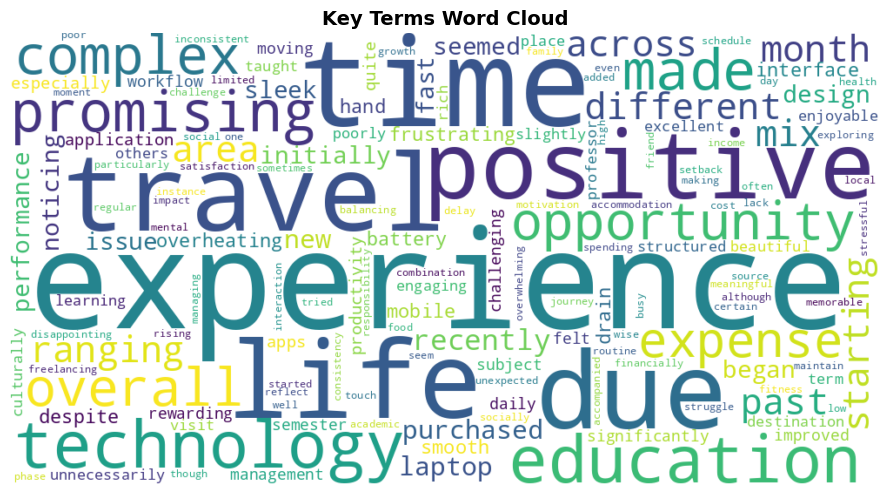

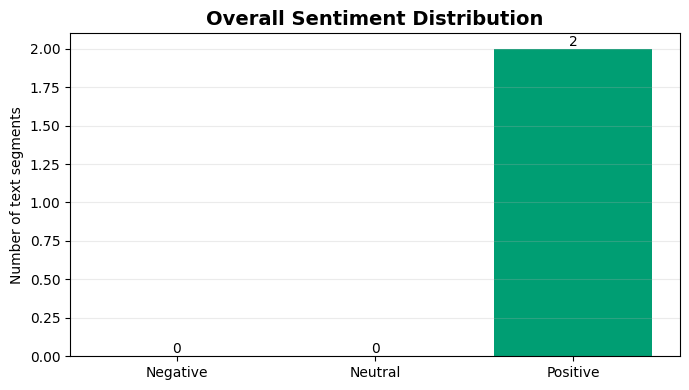

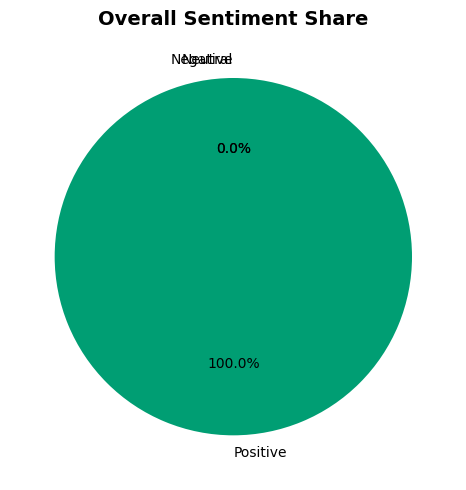

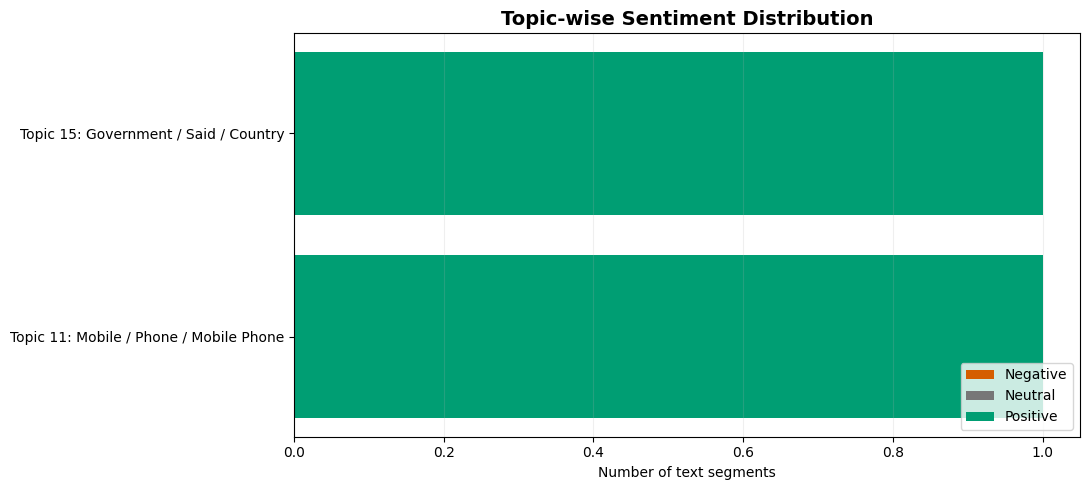

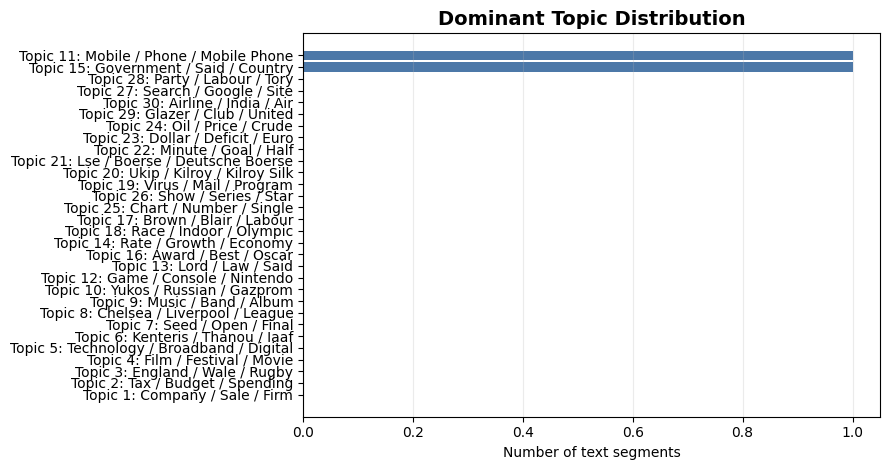

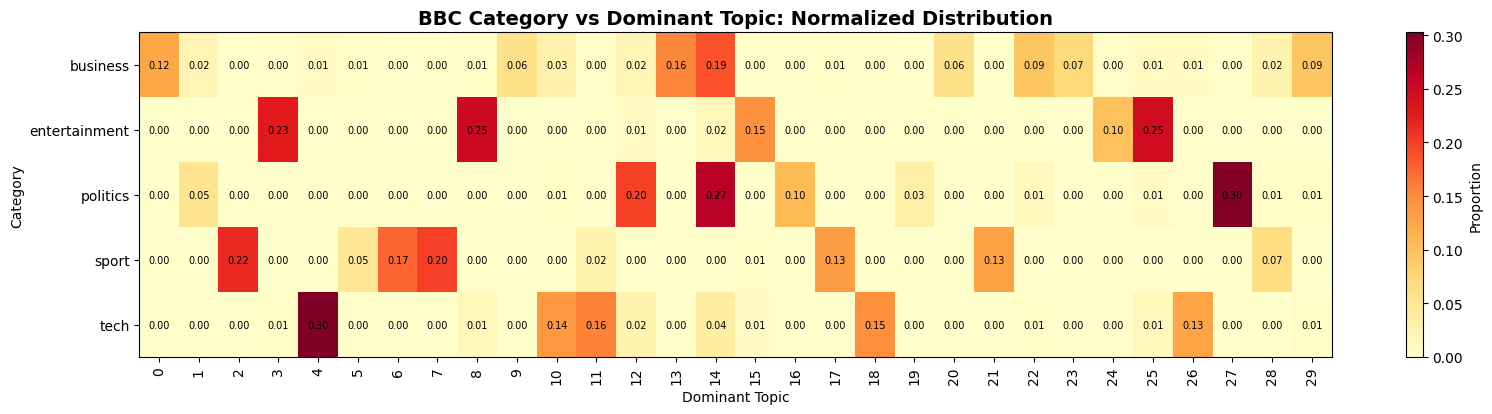

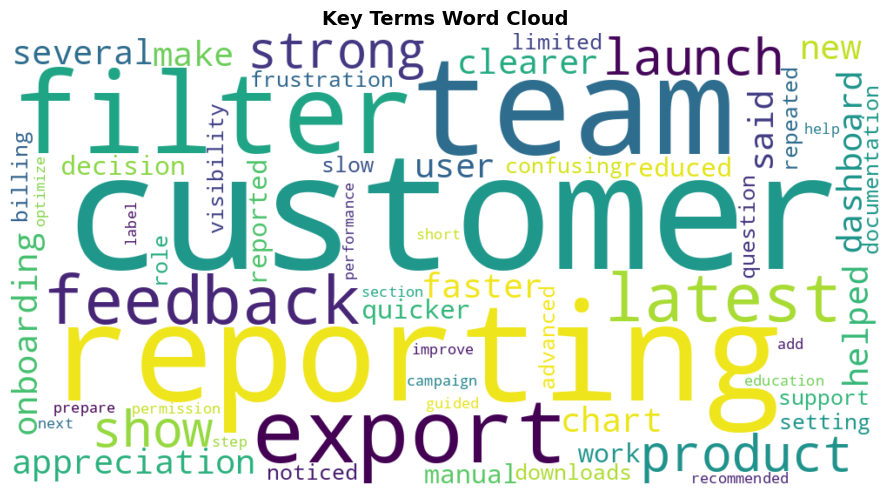

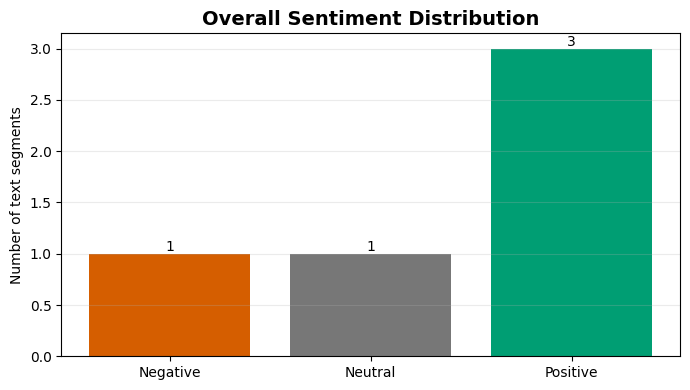

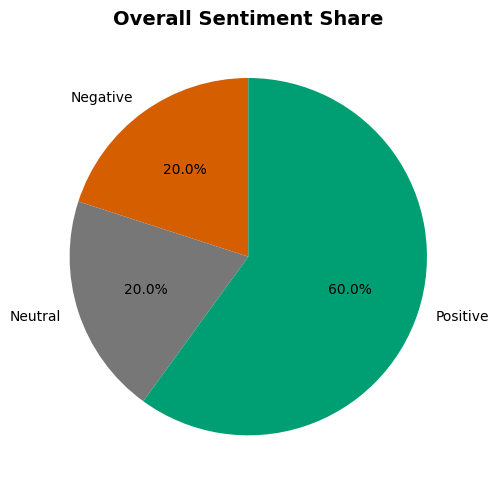

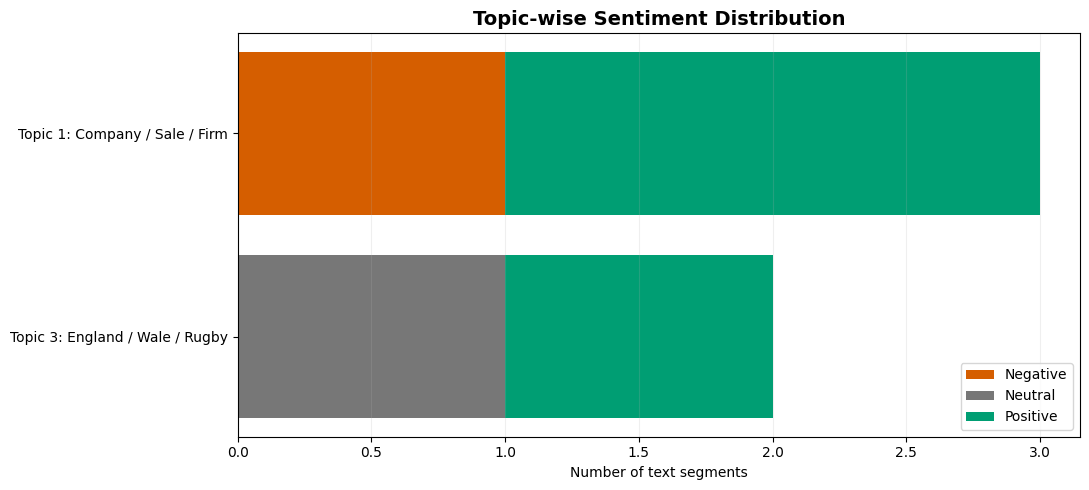

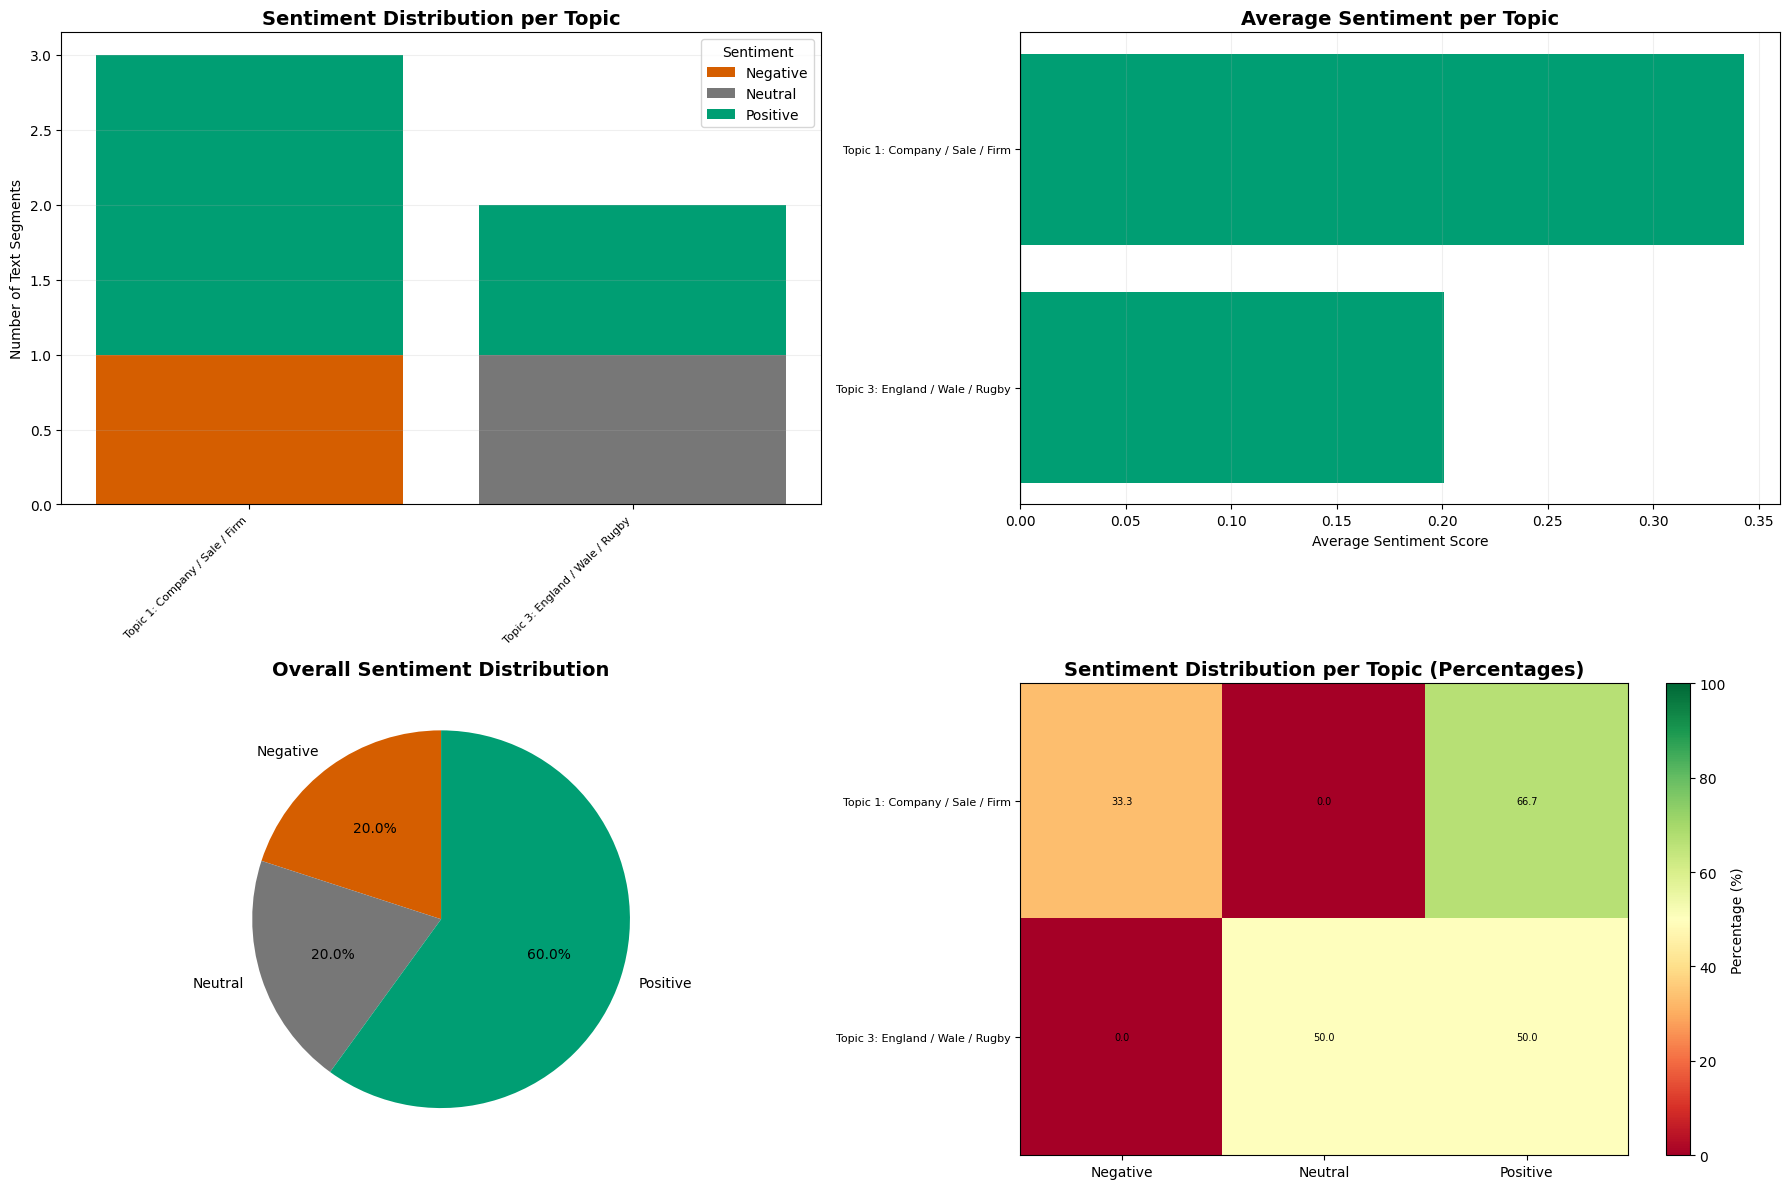

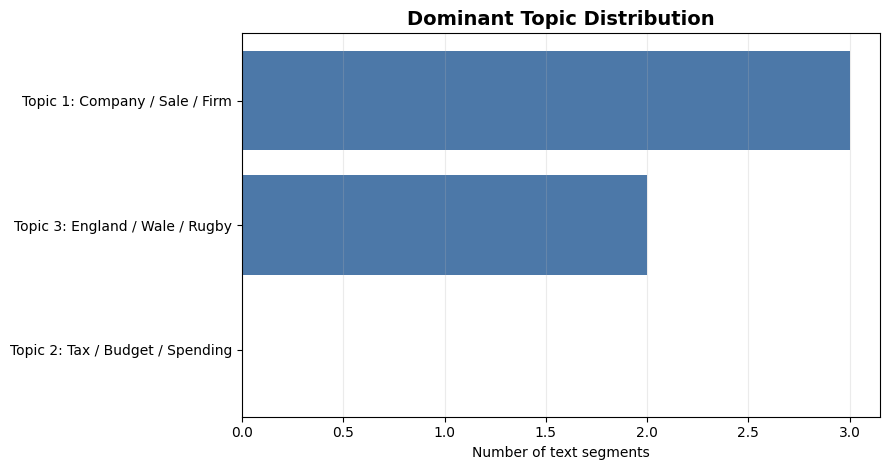

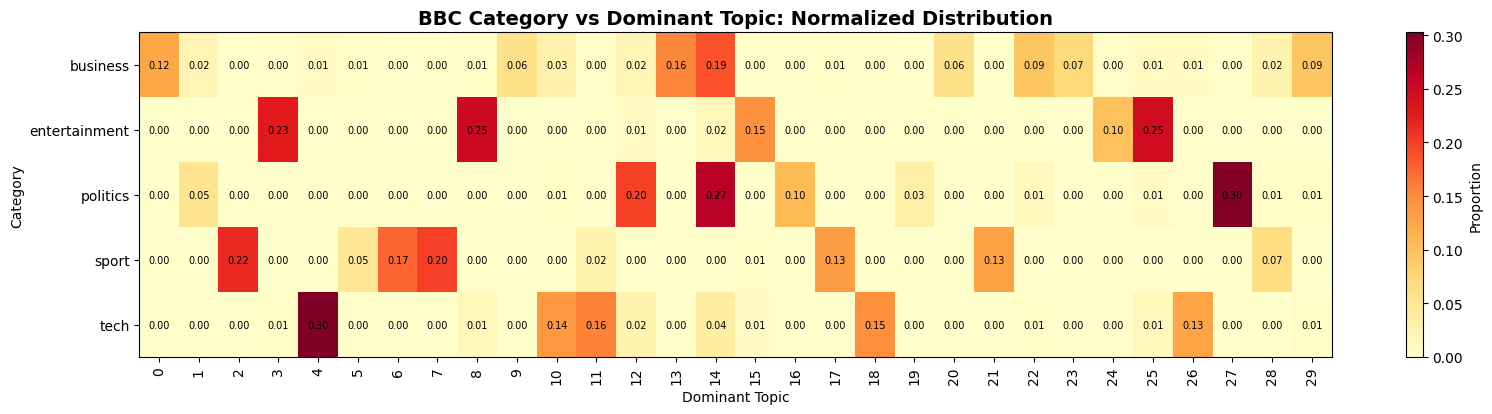

In [17]:
sample_text = """
Customer feedback from the latest product launch shows strong appreciation for the new dashboard, faster onboarding, and clearer reporting.
Several users said the charts helped their teams make quicker decisions and reduced manual reporting work.
However, some customers reported frustration with confusing filters, slow export downloads, and limited documentation for advanced settings.
Support teams also noticed repeated questions about billing visibility and role permissions.
The recommended next step is to improve the filter labels, add a guided help section, optimize export performance, and prepare a short customer education campaign.
"""

sample_result = analyze_text(sample_text, title='Sample Product Feedback', n_topics=3, summary_sentences=3)
display(sample_result['topic_df'])
display(sample_result['sentiment_df'][['Label', 'Compound', 'Segment Preview']])
if not sample_result['category_df'].empty:
    display(sample_result['category_df'])
display(Markdown(sample_result['insight_markdown']))

## Gradio Web Interface

Run the next cell in Colab to launch the webpage. Use the public Gradio link if Colab provides one.

In [18]:
def run_narrativenexus(pasted_text, uploaded_file, csv_text_column, n_topics, summary_sentences):
    try:
        file_text = read_uploaded_file(uploaded_file, csv_text_column) if uploaded_file else ''
        combined_text = '\n'.join(part for part in [pasted_text or '', file_text] if part.strip())
        if not combined_text.strip():
            raise ValueError('Paste text, upload a supported document, or do both before running analysis.')
        result = analyze_text(
            combined_text,
            title='NarrativeNexus Analysis Report',
            n_topics=int(n_topics),
            summary_sentences=int(summary_sentences),
        )
        return (
            result['insight_markdown'],
            result['topic_df'],
            result['sentiment_df'],
            result['category_df'],
            result['document_topic_sentiment_matrix'],
            result['document_topic_sentiment_stats'],
            result['category_topic_counts'],
            result['category_topic_proportions'],
            result['category_topic_heatmap_fig'],
            result['topic_sentiment_matrix'],
            result['topic_sentiment_stats'],
            result['topic_sentiment_insights'],
            result['wordcloud_fig'],
            result['sentiment_fig'],
            result['sentiment_pie_fig'],
            result['document_topic_sentiment_fig'],
            result['sentiment_dashboard_fig'],
            result['topic_fig'],
            result['report_path'],
        )
    except Exception as exc:
        empty_df = pd.DataFrame()
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.axis('off')
        ax.text(0.5, 0.5, 'No visualization available', ha='center', va='center')
        message = f'## Analysis could not be completed\n{exc}'
        return message, empty_df, empty_df, empty_df, empty_df, empty_df, empty_df, empty_df, fig, empty_df, empty_df, '', fig, fig, fig, fig, fig, fig, None


app_css = """
.gradio-container {max-width: 1180px !important; margin: auto;}
#nn-title {padding: 18px 0 6px 0;}
#nn-title h1 {font-size: 34px; margin-bottom: 6px;}
#nn-title p {font-size: 16px; color: #444;}
.nn-note {border-left: 4px solid #2f6f73; padding: 10px 14px; background: #f6fbfb;}
button.primary {min-height: 44px;}
"""

with gr.Blocks(title='NarrativeNexus: BBC News-Trained Text Analysis', css=app_css) as demo:
    gr.Markdown(
        '# NarrativeNexus\nUpload a document or paste text to analyze themes, BBC News category signals, sentiment, summaries, and next steps.',
        elem_id='nn-title',
    )
    gr.Markdown(
        f"Model status: {BBC_NEWS_MODELS['status'] if 'BBC_NEWS_MODELS' in globals() else 'BBC News model not initialized.'}",
        elem_classes=['nn-note'],
    )

    with gr.Row():
        with gr.Column(scale=1, min_width=320):
            pasted_text = gr.Textbox(
                label='Paste text',
                lines=14,
                placeholder='Paste articles, reports, reviews, social posts, or notes...',
            )
            uploaded_file = gr.File(label='Upload document', file_types=['.txt', '.csv', '.docx'], type='filepath')
            csv_text_column = gr.Textbox(label='CSV text column', placeholder='Optional. Leave blank to combine text columns.')
            n_topics = gr.Slider(30, 60, value=30, step=1, label='Topics to show')
            summary_sentences = gr.Slider(2, 8, value=5, step=1, label='Summary sentences')
            analyze_button = gr.Button('Analyze', variant='primary')

        with gr.Column(scale=2):
            with gr.Tabs():
                with gr.Tab('Insights'):
                    insights = gr.Markdown(label='Expanded Insights')
                with gr.Tab('Tables'):
                    topic_table = gr.Dataframe(label='Topic Keywords and Distribution', wrap=True)
                    category_table = gr.Dataframe(label='BBC Category Predictions', wrap=True)
                    sentiment_table = gr.Dataframe(label='Sentiment by Text Segment', wrap=True)
                    document_topic_sentiment_matrix_table = gr.Dataframe(label='Uploaded Text: Topic-wise Sentiment Matrix', wrap=True)
                    document_topic_sentiment_stats_table = gr.Dataframe(label='Uploaded Text: Sentiment Statistics per Topic', wrap=True)
                with gr.Tab('BBC Dataset Diagnostics'):
                    gr.Markdown('Training dataset diagnostics from the BBC News model, including category-topic cross-tabulation, normalized proportions, heatmap, and topic-level sentiment.')
                    category_topic_counts_table = gr.Dataframe(label='Cross-tabulation of Category vs Dominant Topic (Frequencies)', wrap=True)
                    category_topic_proportions_table = gr.Dataframe(label='Normalized Cross-tabulation of Category vs Dominant Topic (Proportions)', wrap=True)
                    category_topic_heatmap = gr.Plot(label='Heatmap of Normalized Topic Distribution')
                    topic_sentiment_matrix_table = gr.Dataframe(label='Topic x Sentiment Matrix', wrap=True)
                    topic_sentiment_stats_table = gr.Dataframe(label='Sentiment Statistics per Topic', wrap=True)
                    topic_sentiment_insights_box = gr.Markdown(label='Topic Sentiment Insights')
                with gr.Tab('Visuals'):
                    wordcloud_plot = gr.Plot(label='Word Cloud')
                    sentiment_plot = gr.Plot(label='Overall Sentiment Bar Chart')
                    sentiment_pie_plot = gr.Plot(label='Overall Sentiment Pie Chart')
                    document_topic_sentiment_plot = gr.Plot(label='Topic-wise Sentiment Distribution')
                    sentiment_dashboard_plot = gr.Plot(label='Combined Sentiment Dashboard')
                    topic_plot = gr.Plot(label='Topic Chart')
                with gr.Tab('Report'):
                    report_file = gr.File(label='Download Markdown Report')

    analyze_button.click(
        fn=run_narrativenexus,
        inputs=[pasted_text, uploaded_file, csv_text_column, n_topics, summary_sentences],
        outputs=[
            insights,
            topic_table,
            sentiment_table,
            category_table,
            document_topic_sentiment_matrix_table,
            document_topic_sentiment_stats_table,
            category_topic_counts_table,
            category_topic_proportions_table,
            category_topic_heatmap,
            topic_sentiment_matrix_table,
            topic_sentiment_stats_table,
            topic_sentiment_insights_box,
            wordcloud_plot,
            sentiment_plot,
            sentiment_pie_plot,
            document_topic_sentiment_plot,
            sentiment_dashboard_plot,
            topic_plot,
            report_file,
        ],
    )

# In Colab, share=True usually creates a public temporary URL.
demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a58dcea038cf0a1b46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Expected Deliverables Checklist

- Fully functional dynamic text analysis platform for pasted text and `.txt`, `.csv`, `.docx` inputs.
- Topic modeling with NMF and optional LDA comparison topics.
- Sentiment analysis with VADER.
- Extractive summarization and actionable recommendation logic.
- Interactive Gradio webpage inside the notebook.
- Visual dashboard with word cloud, sentiment chart, and topic distribution chart.
- Downloadable Markdown report.
- Clear documentation of methodology, architecture, implementation, and findings.

## Conclusion

NarrativeNexus provides a complete, notebook-contained platform for transforming unstructured text into interpretable themes, sentiment signals, concise summaries, and practical recommendations. The Gradio interface makes the system accessible to non-technical users while the notebook cells preserve the full implementation for review, testing, and future improvement.